In [63]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import optris_csv as ocsv
from scipy.signal import medfilt
import numpy as np

longData1_1 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData1_1.dat",";").build_array_data()
longData1_2 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData1_2.dat",";").build_array_data()
longData1_2 = longData1_2[longData1_2["time"] >= np.max(longData1_1["time"])]
longData1_1 = longData1_1["Detector Area"]
longData1_2 = longData1_2["Detector Area"]

longData2_1 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData2_1.dat",";").build_array_data()
longData2_2 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData2_2.dat",";").build_array_data()
longData2_2 = longData2_2[longData2_2["time"] >= np.max(longData2_1["time"])]
longData2_1 = longData2_1["Detector Area"]
longData2_2 = longData2_2["Detector Area"]

longData3_1 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData3_1.dat",";").build_array_data()
longData3_2 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData3_2.dat",";").build_array_data()
longData3_2 = longData3_2[longData3_2["time"] >= np.max(longData3_1["time"])]
longData3_1 = longData3_1["Detector Area"]
longData3_2 = longData3_2["Detector Area"]

longData4 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData4.dat", ";").build_array_data()
longData5 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData5.dat", ";").build_array_data()
longData6 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData6.dat", ";").build_array_data()
longData7 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData7.dat", ";").build_array_data()
longData8 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData8.dat", ";").build_array_data()
longData9 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData9.dat", ";").build_array_data()
longData10 = ocsv.OptrisDataset("./Caleb/New PC Data/LongData10.dat", ";").build_array_data()
longData11 = ocsv.OptrisDataset("./Caleb/New PC Data/MidData1.dat", ";").build_array_data()
longData12 = ocsv.OptrisDataset("./Caleb/New PC Data/MidData2.dat", ";").build_array_data()


data1 = np.concatenate((longData1_1,longData1_2),axis=0)
data2 = np.concatenate((longData2_1,longData2_2),axis=0)
data3 = np.concatenate((longData3_1,longData3_2),axis=0)
data4 = longData4["Detector Area"]
data5 = longData5["Detector Area"]
data6 = longData6["Detector Area"]
data7 = longData7["Detector Area"]
data8 = longData8["Detector Area"]
data9 = longData9["Detector Area"]
data10 = longData10["Detector Area"]
data11 = longData9["Detector Area"]
data12 = longData10["Detector Area"]

225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found
225 local maxima found


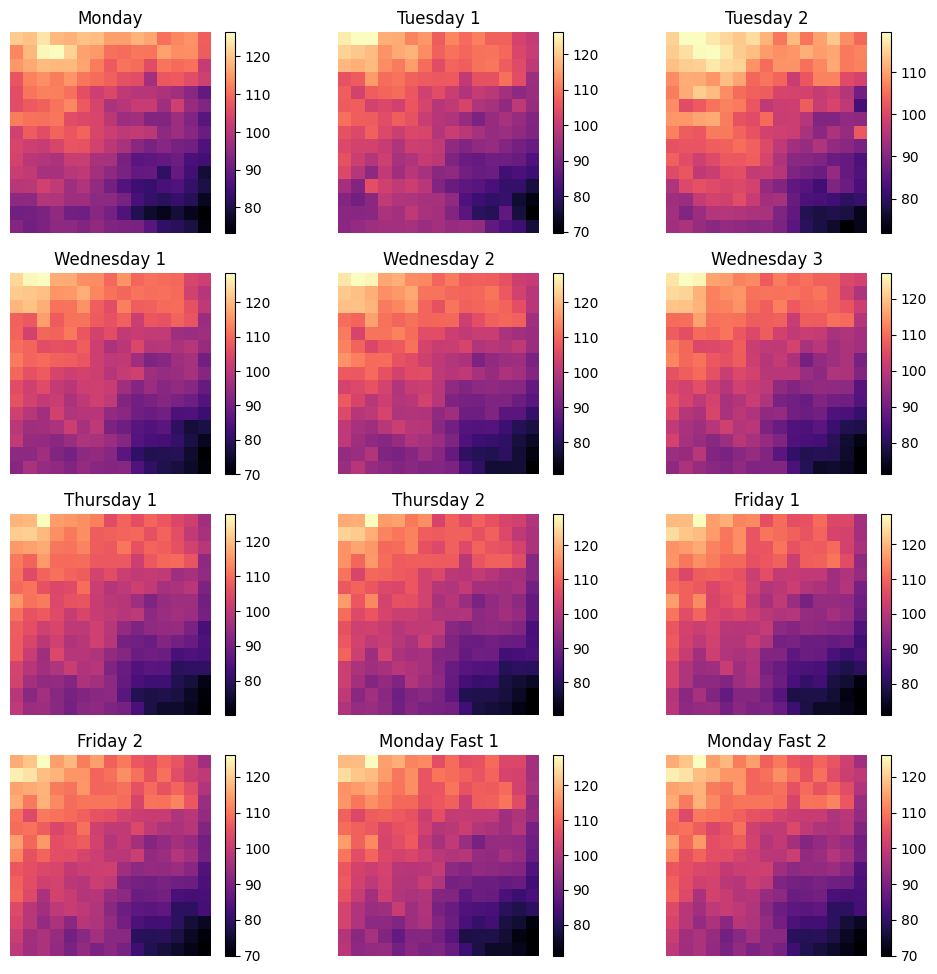

In [65]:
import temperature_analysis as ta
import matplotlib.pyplot as plt


plt.close(1)
fig, ax = plt.subplots(4, 3, figsize = (12,12), num=1)

sample1 = ta.tempMap(ta.getMaxima(medfilt(data1, kernel_size = 15), trigger = 3), "Left", "Down")
sample2 = ta.tempMap(ta.getMaxima(medfilt(data2, kernel_size = 15), trigger = 3), "Left", "Down")
sample3 = ta.tempMap(ta.getMaxima(medfilt(data3, kernel_size = 15), trigger = 3), "Left", "Down")
sample4 = ta.tempMap(ta.getMaxima(medfilt(data4, kernel_size = 15), trigger = 3), "Left", "Down")
sample5 = ta.tempMap(ta.getMaxima(medfilt(data5, kernel_size = 15), trigger = 3), "Left", "Down")
sample6 = ta.tempMap(ta.getMaxima(medfilt(data6, kernel_size = 15), trigger = 3), "Left", "Down")
sample7 = ta.tempMap(ta.getMaxima(medfilt(data7, kernel_size = 15), trigger = 3), "Left", "Down")
sample8 = ta.tempMap(ta.getMaxima(medfilt(data8, kernel_size = 15), trigger = 3), "Left", "Down")
sample9 = ta.tempMap(ta.getMaxima(medfilt(data9, kernel_size = 15), trigger = 3), "Left", "Down")
sample10 = ta.tempMap(ta.getMaxima(medfilt(data10, kernel_size = 15), trigger = 3), "Left", "Down")
sample11 = ta.tempMap(ta.getMaxima(medfilt(data11, kernel_size = 15), trigger = 3), "Left", "Down")
sample12 = ta.tempMap(ta.getMaxima(medfilt(data12, kernel_size = 15), trigger = 3), "Left", "Down")

samples = np.array([sample1, sample2, sample3, sample4, sample5, sample6, sample7, sample8, sample9, sample10, sample11, sample12])
titles = np.array(["Monday", "Tuesday 1", "Tuesday 2", "Wednesday 1", "Wednesday 2", "Wednesday 3", "Thursday 1", "Thursday 2", "Friday 1", "Friday 2", "Monday Fast 1", "Monday Fast 2"])

for i in range(len(samples)):
    img = ax[i//3, i%3].imshow(samples[i], interpolation='nearest',
                            cmap = 'magma',
                            origin='lower',
                            )
    ax[i//3, i%3].set_title(titles[i])
    ax[i//3, i%3].set_axis_off()
    plt.colorbar(img, cmap = 'magma')

plt.show()


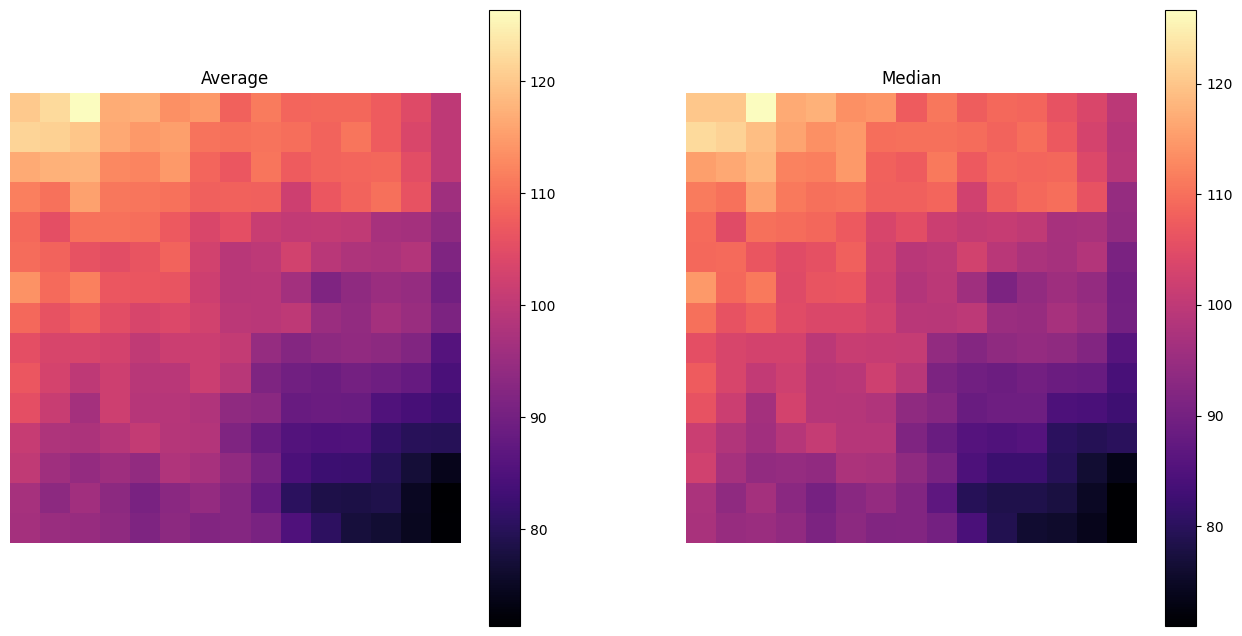

In [66]:
plt.close(2)
fig, ax = plt.subplots(1, 2, figsize = (16,8), num = 2)

mean = np.mean(samples, axis = 0)
median = np.median(samples, axis = 0)

img = ax[0].imshow(mean, interpolation = 'nearest',
                cmap = 'magma',
                origin = 'lower',)
ax[0].set_title("Average")
ax[0].set_axis_off()
plt.colorbar(img, cmap = 'magma')

img = ax[1].imshow(median, interpolation = 'nearest',
                cmap = 'magma',
                origin = 'lower',)
ax[1].set_title("Median")
ax[1].set_axis_off()
plt.colorbar(img, cmap = 'magma')

plt.show()